In [ ]:
from utils import load_data, split_data, preprocess, truncate_text
from utils import compare_errors, plot_error_matrix, print_error_examples, analyze_common_cases

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [4]:
df, X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [5]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

In [6]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [7]:
bi_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])

In [8]:
X_train = X_train.apply(preprocess)
X_val = X_val.apply(preprocess)
X_test = X_test.apply(preprocess)

### Eksperyment 5.1: klasyfikacj binarna
Jak trudne jest odseparowanie tekstu napisanego przez osobę w normalnym stanie psychicznym od tekstu wskazującego, że autor/autorka potencjalnie zmaga się z trudnością w obszarze zdrowia psychicznego?

In [9]:
df['binary_status'] = df['status'].apply(
    lambda x: 'Normal' if x == 'Normal' else 'Problem'
)

print("Binary class distribution:")
print((df['binary_status'].value_counts(normalize=True) * 100).round(2))

Binary class distribution:
binary_status
Problem    68.98
Normal     31.02
Name: proportion, dtype: float64


In [10]:
y_train_bin = y_train.apply(lambda x: 'Normal' if x == 'Normal' else 'Problem')
y_val_bin = y_val.apply(lambda x: 'Normal' if x == 'Normal' else 'Problem')
y_test_bin = y_test.apply(lambda x: 'Normal' if x == 'Normal' else 'Problem')

In [11]:
baseline.fit(X_train, y_train_bin)
y_val_pred_bin = baseline.predict(X_val)
f1_macro_bin = f1_score(y_val_bin, y_val_pred_bin, average='macro')

print(classification_report(y_val_bin, y_val_pred_bin))
print(f"F1 macro: {f1_macro_bin:.2f}")

              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91      2451
     Problem       0.96      0.96      0.96      5451

    accuracy                           0.94      7902
   macro avg       0.94      0.93      0.93      7902
weighted avg       0.94      0.94      0.94      7902

F1 macro: 0.93


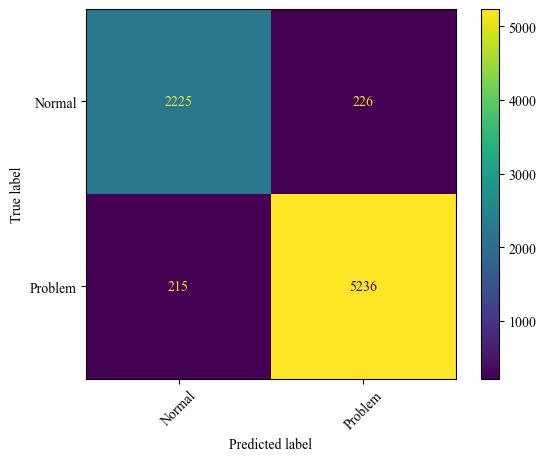

In [12]:
cm_bin = confusion_matrix(y_val_bin, y_val_pred_bin)
ConfusionMatrixDisplay.from_predictions(
    y_val_bin, y_val_pred_bin,
    xticks_rotation=45)

In [13]:
svm_pipeline.fit(X_train, y_train_bin)
y_val_pred_svm_bin = svm_pipeline.predict(X_val)
f1_macro_svm_bin = f1_score(y_val_bin, y_val_pred_svm_bin, average='macro')

print(classification_report(y_val_bin, y_val_pred_svm_bin))
print(f"F1 macro: {f1_macro_svm_bin:.2f}")

              precision    recall  f1-score   support

      Normal       0.92      0.91      0.92      2451
     Problem       0.96      0.96      0.96      5451

    accuracy                           0.95      7902
   macro avg       0.94      0.94      0.94      7902
weighted avg       0.95      0.95      0.95      7902

F1 macro: 0.94


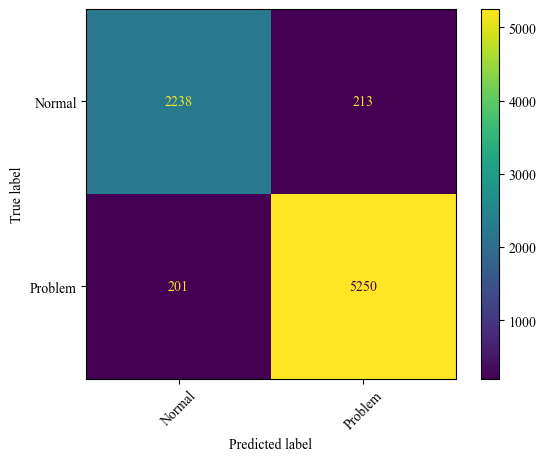

In [14]:
cm_bin_svm = confusion_matrix(y_val_bin, y_val_pred_svm_bin)
ConfusionMatrixDisplay.from_predictions(
    y_val_bin, y_val_pred_svm_bin,
    xticks_rotation=45)

In [15]:
bi_svm_pipeline.fit(X_train, y_train_bin)
y_val_pred_bi_svm_bin = bi_svm_pipeline.predict(X_val)
f1_macro_bi_svm_bin = f1_score(y_val_bin, y_val_pred_bi_svm_bin, average='macro')

print(classification_report(y_val_bin, y_val_pred_bi_svm_bin))
print(f"F1 macro: {f1_macro_bi_svm_bin:.2f}")

              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92      2451
     Problem       0.96      0.98      0.97      5451

    accuracy                           0.95      7902
   macro avg       0.95      0.94      0.95      7902
weighted avg       0.95      0.95      0.95      7902

F1 macro: 0.95


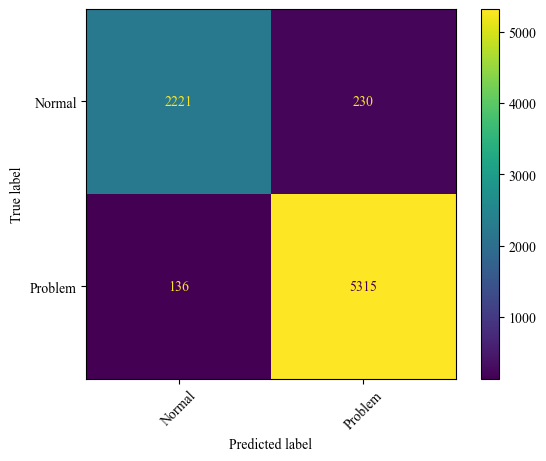

In [16]:
cm_bin_bi_svm = confusion_matrix(y_val_bin, y_val_pred_bi_svm_bin)
ConfusionMatrixDisplay.from_predictions(
    y_val_bin, y_val_pred_bi_svm_bin,
    xticks_rotation=45)

In [17]:
def evaluate_length(X_train, X_val, y_train, y_val):
    lens = [50*n for n in range(1, 21)]
    f1_scores_lr = []
    f1_scores_svm = []
    f1_scores_bi_svm = []

    for len in lens:
        X_train_trunc = X_train.apply(lambda x: truncate_text(x, len))
        X_val_trunc = X_val.apply(lambda x: truncate_text(x, len))

        baseline.fit(X_train_trunc, y_train)
        y_val_pred_lr_trunc = baseline.predict(X_val_trunc)
        f1_macro_lr_trunc = f1_score(y_val, y_val_pred_lr_trunc, average='macro')

        svm_pipeline.fit(X_train_trunc, y_train)
        y_val_pred_svm_trunc = svm_pipeline.predict(X_val_trunc)
        f1_macro_svm_trunc = f1_score(y_val, y_val_pred_svm_trunc, average='macro')

        bi_svm_pipeline.fit(X_train_trunc, y_train)
        y_val_pred_bi_svm_trunc = bi_svm_pipeline.predict(X_val_trunc)
        f1_macro_bi_svm_trunc = f1_score(y_val, y_val_pred_bi_svm_trunc, average='macro')
        
        f1_scores_lr.append(f1_macro_lr_trunc)
        f1_scores_svm.append(f1_macro_svm_trunc)
        f1_scores_bi_svm.append(f1_macro_bi_svm_trunc)
        print(f"Length={len}, LR F1 macro: {f1_macro_lr_trunc:.2f}, SVM F1 macro: {f1_macro_svm_trunc:.2f}, Bi-SVM F1 macro: {f1_macro_bi_svm_trunc:.2f}")

    return lens, f1_scores_lr, f1_scores_svm, f1_scores_bi_svm

In [18]:
lens, f1_scores_bin_lr, f1_scores_bin_svm, f1_scores_bin_bi_svm = evaluate_length(X_train, X_val, y_train_bin, y_val_bin)

Length=50, LR F1 macro: 0.83, SVM F1 macro: 0.84, Bi-SVM F1 macro: 0.85
Length=100, LR F1 macro: 0.88, SVM F1 macro: 0.89, Bi-SVM F1 macro: 0.89
Length=150, LR F1 macro: 0.91, SVM F1 macro: 0.91, Bi-SVM F1 macro: 0.91
Length=200, LR F1 macro: 0.92, SVM F1 macro: 0.92, Bi-SVM F1 macro: 0.93
Length=250, LR F1 macro: 0.92, SVM F1 macro: 0.93, Bi-SVM F1 macro: 0.93
Length=300, LR F1 macro: 0.93, SVM F1 macro: 0.93, Bi-SVM F1 macro: 0.93
Length=350, LR F1 macro: 0.93, SVM F1 macro: 0.93, Bi-SVM F1 macro: 0.94
Length=400, LR F1 macro: 0.93, SVM F1 macro: 0.93, Bi-SVM F1 macro: 0.94
Length=450, LR F1 macro: 0.93, SVM F1 macro: 0.94, Bi-SVM F1 macro: 0.94
Length=500, LR F1 macro: 0.93, SVM F1 macro: 0.94, Bi-SVM F1 macro: 0.94
Length=550, LR F1 macro: 0.93, SVM F1 macro: 0.94, Bi-SVM F1 macro: 0.94
Length=600, LR F1 macro: 0.93, SVM F1 macro: 0.94, Bi-SVM F1 macro: 0.94
Length=650, LR F1 macro: 0.93, SVM F1 macro: 0.94, Bi-SVM F1 macro: 0.94
Length=700, LR F1 macro: 0.93, SVM F1 macro: 0.94, B

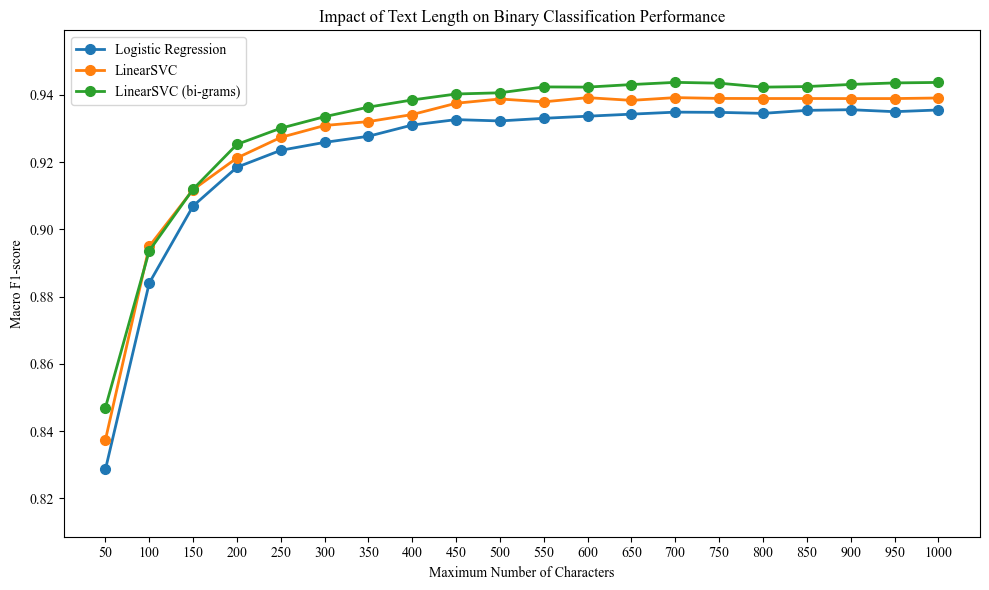

In [19]:
# wizualizacja wpływu długości tekstu na F1 macro (klasyfikacja binarna)
plt.figure(figsize=(10, 6))

plt.plot(
    lens,
    f1_scores_bin_lr,
    marker='o',
    linewidth=2,
    markersize=7,
    label='Logistic Regression'
)

plt.plot(
    lens,
    f1_scores_bin_svm,
    marker='o',
    linewidth=2,
    markersize=7,
    label='LinearSVC'
)

plt.plot(
    lens,
    f1_scores_bin_bi_svm,
    marker='o',
    linewidth=2,
    markersize=7,
    label='LinearSVC (bi-grams)'
)

plt.title("Impact of Text Length on Binary Classification Performance")
plt.xlabel("Maximum Number of Characters")
plt.ylabel("Macro F1-score")
plt.xticks(lens)

plt.legend()
plt.ylim(
    min(min(f1_scores_bin_lr), min(f1_scores_bin_svm)) - 0.02,
    max(max(f1_scores_bin_lr), max(f1_scores_bin_svm)) + 0.02
)

plt.tight_layout()
plt.show()

### Eksperyment 5.2: klasyfikacj problemów
Czy klasyfikacja problemu psychicznego/emocjonalnego jest łatwiejsza, gdy wiemy, że problem ten występuje?

In [20]:
problem_mask_train = y_train != 'Normal'
problem_mask_val = y_val != 'Normal'
problem_mask_test = y_test != 'Normal'

X_train_problem = X_train[problem_mask_train]
y_train_problem = y_train[problem_mask_train]

X_val_problem = X_val[problem_mask_val]
y_val_problem = y_val[problem_mask_val]

X_test_problem = X_test[problem_mask_test]
y_test_problem = y_test[problem_mask_test]

In [21]:
baseline.fit(X_train_problem, y_train_problem)
y_val_pred_problem = baseline.predict(X_val_problem)
f1_macro_problem = f1_score(y_val_problem, y_val_pred_problem, average='macro')

print(classification_report(y_val_problem, y_val_pred_problem))
print(f"F1 macro: {f1_macro_problem:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.84      0.77      0.81       576
             Bipolar       0.89      0.65      0.75       416
          Depression       0.68      0.78      0.73      2311
Personality disorder       0.90      0.48      0.63       162
              Stress       0.73      0.56      0.63       388
            Suicidal       0.71      0.69      0.70      1598

            accuracy                           0.72      5451
           macro avg       0.79      0.66      0.71      5451
        weighted avg       0.73      0.72      0.72      5451

F1 macro: 0.71


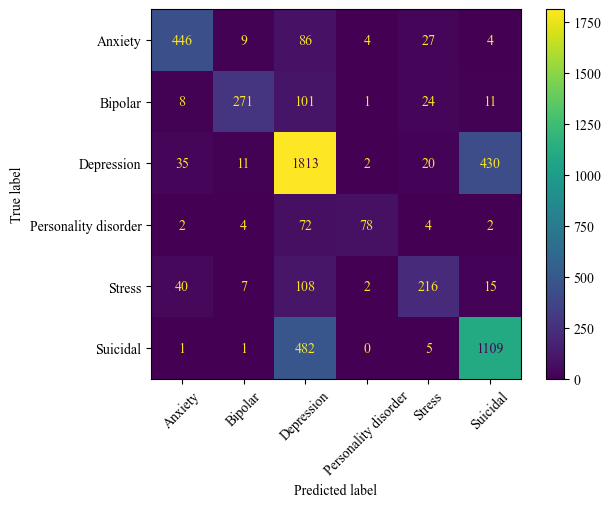

In [22]:
cm_problem = confusion_matrix(y_val_problem, y_val_pred_problem)
ConfusionMatrixDisplay.from_predictions(
    y_val_problem, y_val_pred_problem,
    xticks_rotation=45)

In [23]:
svm_pipeline.fit(X_train_problem, y_train_problem)
y_val_pred_svm_problem = svm_pipeline.predict(X_val_problem)
f1_macro_svm_problem = f1_score(y_val_problem, y_val_pred_svm_problem, average='macro')

print(classification_report(y_val_problem, y_val_pred_svm_problem))
print(f"F1 macro: {f1_macro_svm_problem:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.83      0.80      0.81       576
             Bipolar       0.84      0.70      0.76       416
          Depression       0.70      0.75      0.72      2311
Personality disorder       0.82      0.59      0.69       162
              Stress       0.73      0.59      0.65       388
            Suicidal       0.67      0.69      0.68      1598

            accuracy                           0.72      5451
           macro avg       0.76      0.69      0.72      5451
        weighted avg       0.72      0.72      0.72      5451

F1 macro: 0.72


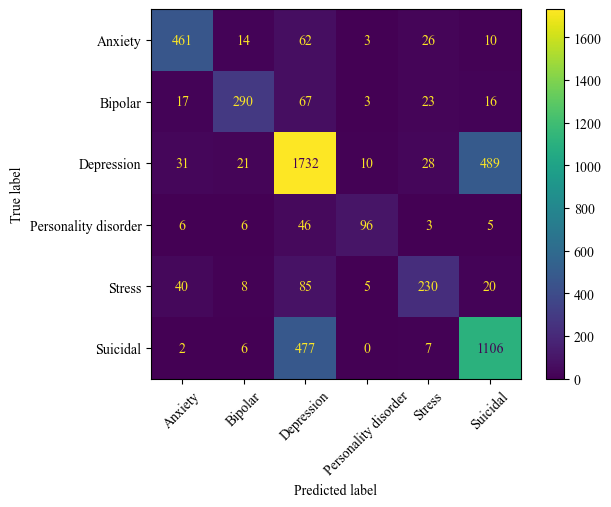

In [24]:
cm_problem_svm = confusion_matrix(y_val_problem, y_val_pred_svm_problem)
ConfusionMatrixDisplay.from_predictions(
    y_val_problem, y_val_pred_svm_problem,
    xticks_rotation=45)

In [25]:
bi_svm_pipeline.fit(X_train_problem, y_train_problem)
y_val_pred_bi_svm_problem = bi_svm_pipeline.predict(X_val_problem)
f1_macro_bi_svm_problem = f1_score(y_val_problem, y_val_pred_bi_svm_problem, average='macro')

print(classification_report(y_val_problem, y_val_pred_bi_svm_problem))
print(f"F1 macro: {f1_macro_bi_svm_problem:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.84      0.82      0.83       576
             Bipolar       0.89      0.74      0.81       416
          Depression       0.70      0.77      0.73      2311
Personality disorder       0.92      0.56      0.70       162
              Stress       0.80      0.56      0.66       388
            Suicidal       0.69      0.71      0.70      1598

            accuracy                           0.73      5451
           macro avg       0.81      0.69      0.74      5451
        weighted avg       0.74      0.73      0.73      5451

F1 macro: 0.74


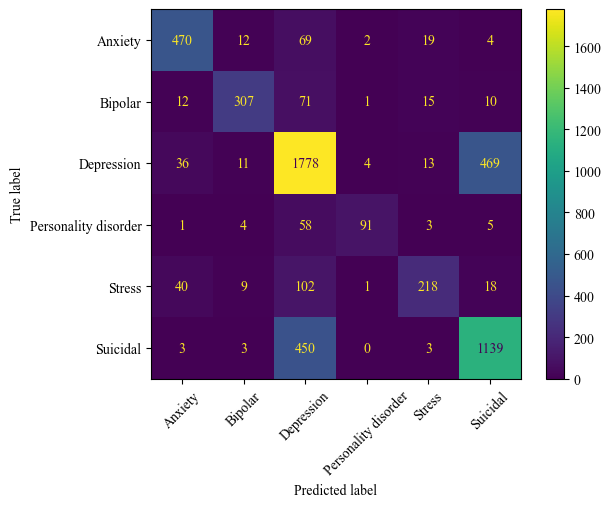

In [26]:
cm_problem_bi_svm = confusion_matrix(y_val_problem, y_val_pred_bi_svm_problem)
ConfusionMatrixDisplay.from_predictions(
    y_val_problem, y_val_pred_bi_svm_problem,
    xticks_rotation=45)

### Eksperyment 5.3: klasyfikacj hierarchiczna
Czy przeprowadzenie klasyfikacji etapami (pierwsze rozpoznanie czy problem występuje, a następnei ewentualna jego precyzyjna identyfikacja) poprawia jakość modelu?

In [27]:
baseline.fit(X_train, y_train)
y_val_pred = baseline.predict(X_val)

svm_pipeline.fit(X_train, y_train)
y_val_pred_svm = svm_pipeline.predict(X_val)

bi_svm_pipeline.fit(X_train, y_train)
y_val_pred_bi_svm = bi_svm_pipeline.predict(X_val)

In [28]:
bin_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1_000))
])
problem_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1_000))
])

bin_pipeline.fit(X_train, y_train_bin)
problem_pipeline.fit(X_train_problem, y_train_problem)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=1000))])

In [29]:
def hierarchical_predict(X):
    final_pred = np.array(['Normal']*len(X), dtype=object)
    binary_pred = bin_pipeline.predict(X)

    problem_mask = binary_pred != 'Normal'
    if problem_mask.sum() > 0:
        problem_pred = problem_pipeline.predict(X[problem_mask])
        final_pred[problem_mask] = problem_pred
    return final_pred

In [30]:
y_val_hier_pred = hierarchical_predict(X_val)
f1_macro_hier = f1_score(y_val, y_val_hier_pred, average='macro')

print(classification_report(y_val, y_val_hier_pred))
print(f"F1 macro: {f1_macro_hier:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.73      0.77       576
             Bipolar       0.89      0.63      0.74       416
          Depression       0.66      0.76      0.71      2311
              Normal       0.91      0.91      0.91      2451
Personality disorder       0.87      0.47      0.61       162
              Stress       0.60      0.50      0.55       388
            Suicidal       0.69      0.68      0.68      1598

            accuracy                           0.76      7902
           macro avg       0.78      0.67      0.71      7902
        weighted avg       0.77      0.76      0.76      7902

F1 macro: 0.71


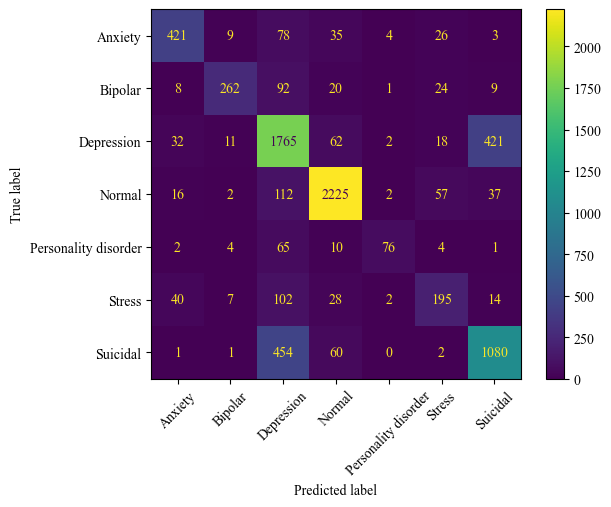

In [31]:
cm_hier = confusion_matrix(y_val, y_val_hier_pred)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_hier_pred,
    xticks_rotation=45)

In [32]:
bin_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])
problem_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

bin_svm_pipeline.fit(X_train, y_train_bin)
problem_svm_pipeline.fit(X_train_problem, y_train_problem)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [33]:
def hierarchical_predict_svm(X):
    final_pred = np.array(['Normal'] * len(X), dtype=object)
    binary_pred = bin_svm_pipeline.predict(X)

    problem_mask = binary_pred != 'Normal'
    if problem_mask.sum() > 0:
        problem_pred = problem_svm_pipeline.predict(X[problem_mask])
        final_pred[problem_mask] = problem_pred
    return final_pred

In [34]:
y_val_hier_svm_pred = hierarchical_predict_svm(X_val)
f1_macro_hier_svm = f1_score(y_val, y_val_hier_svm_pred, average='macro')

print(classification_report(y_val, y_val_hier_svm_pred))
print(f"F1 macro: {f1_macro_hier_svm:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.79      0.77      0.78       576
             Bipolar       0.83      0.68      0.75       416
          Depression       0.69      0.73      0.71      2311
              Normal       0.92      0.91      0.92      2451
Personality disorder       0.81      0.59      0.68       162
              Stress       0.62      0.53      0.57       388
            Suicidal       0.66      0.68      0.67      1598

            accuracy                           0.76      7902
           macro avg       0.76      0.70      0.72      7902
        weighted avg       0.77      0.76      0.76      7902

F1 macro: 0.72


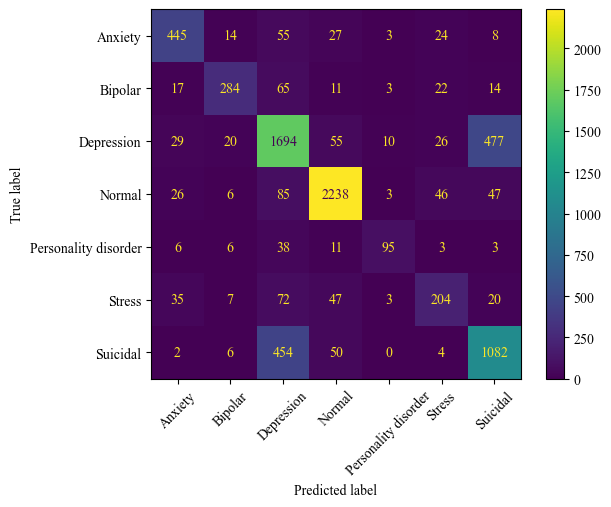

In [35]:
cm_hier_svm = confusion_matrix(y_val, y_val_hier_svm_pred)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_hier_svm_pred,
    xticks_rotation=45)

In [36]:
bin_bi_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])
problem_bi_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("clf", LinearSVC())
])

bin_bi_svm_pipeline.fit(X_train, y_train_bin)
problem_bi_svm_pipeline.fit(X_train_problem, y_train_problem)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('clf', LinearSVC())])

In [37]:
def hierarchical_predict_bi_svm(X):
    final_pred = np.array(['Normal'] * len(X), dtype=object)
    binary_pred = bin_bi_svm_pipeline.predict(X)

    problem_mask = binary_pred != 'Normal'
    if problem_mask.sum() > 0:
        problem_pred = problem_bi_svm_pipeline.predict(X[problem_mask])
        final_pred[problem_mask] = problem_pred
    return final_pred

In [38]:
y_val_hier_bi_svm_pred = hierarchical_predict_bi_svm(X_val)
f1_macro_hier_bi_svm = f1_score(y_val, y_val_hier_bi_svm_pred, average='macro')

print(classification_report(y_val, y_val_hier_bi_svm_pred))
print(f"F1 macro: {f1_macro_hier_bi_svm:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.79      0.80       576
             Bipolar       0.87      0.72      0.79       416
          Depression       0.68      0.76      0.72      2311
              Normal       0.94      0.91      0.92      2451
Personality disorder       0.89      0.56      0.69       162
              Stress       0.68      0.52      0.59       388
            Suicidal       0.67      0.70      0.69      1598

            accuracy                           0.78      7902
           macro avg       0.79      0.71      0.74      7902
        weighted avg       0.78      0.78      0.78      7902

F1 macro: 0.74


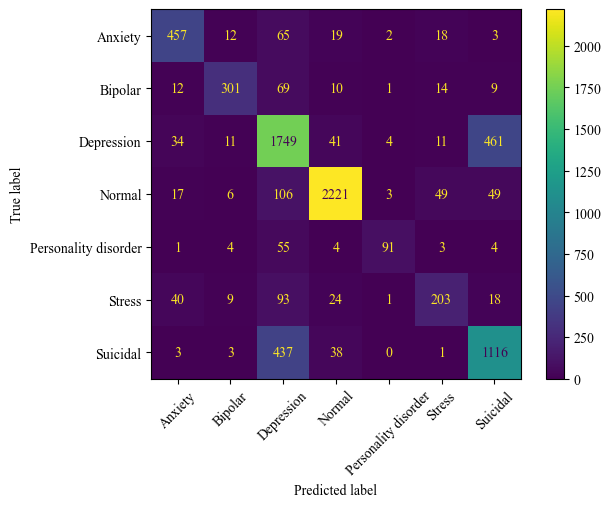

In [39]:
cm_hier_bi_svm = confusion_matrix(y_val, y_val_hier_bi_svm_pred)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_hier_bi_svm_pred,
    xticks_rotation=45)

### Analiza błędów

In [40]:
predictions = {
    "baseline" : y_val_pred,
    "hierarchical" : y_val_hier_pred,
    "svm" : y_val_pred_svm,
    "hierarchical_svm" : y_val_hier_svm_pred,
    "bi_svm" : y_val_pred_bi_svm,
    "hierarchical_bi_svm" : y_val_hier_bi_svm_pred
}

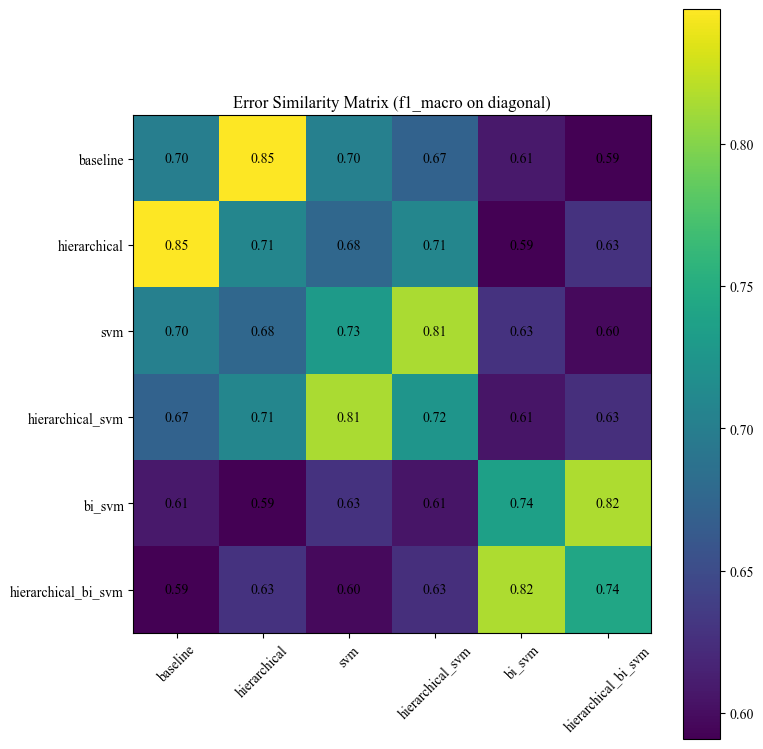

In [41]:
results, metrics = compare_errors(predictions, y_val)
plot_error_matrix(results, metrics, metric='f1_macro')

In [45]:
print_error_examples(
    results,
    X_val,
    y_val,
    predictions,
    n_examples=3
)


baseline vs hierarchical

--- Shared errors ---

ID: 3
TEXT: sense of fear have you ever felt a sense of fear that seemed to take over your body and mind, leaving you feeling helpless? fear can be a paralyzing emotion, preventing us from moving forward in life. but what if there was something you could do about it? what if there were ways to get rid of the se
TRUE: Stress
baseline: Anxiety
hierarchical: Anxiety

ID: 8
TEXT: can’t take it anymore today has been one of the worst days in a long time. out of so many countless times i have wanted to just give up and end it, i kept going. thought i was getting a loan so i could get out of debt and actually have some money to get things i desperately need since i haven’t work
TRUE: Bipolar
baseline: Depression
hierarchical: Stress

ID: 11
TEXT: i always make mistakes, and bad decisions. i have no skills or talents. i have no accomplishments. i feel like a useless person. my parents make me feel stupid, for every mistake that i make. i feel l

In [43]:
analysis = analyze_common_cases(
    predictions,
    y_val,
    X_val,
    k_examples=20
)

ALL MODELS CORRECT

Count: 5267

Class distribution:
Normal                  2136
Depression              1447
Suicidal                 885
Anxiety                  372
Bipolar                  232
Stress                   133
Personality disorder      62
dtype: int64

Examples:

----------------------------------------
ID: 0
TRUE: Normal
TEXT:
@marthastewart proof?

----------------------------------------
ID: 1
TRUE: Depression
TEXT:
when i get told i am a good guy it sometimes drives me near to tears. i have been told how nice i am. how funny i am. how dependable. i have been told many times by different people these things so it must be true right? but i guess i am not good enough. if i was it would not be so hard to find and keep people in my life. i know it sounds self serving and all pity party but its how i feel and the thoughts in my head. i realize and understand that i am not a priority to anyone else. i just wish i

----------------------------------------
ID: 2
TRUE: Norma